In [116]:
#!/usr/bin/env python
# coding: utf-8

In [117]:
import scipy.io
import os
import sys
import h5py
import numpy as np
from scipy.interpolate import interp1d
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sbi import utils as sbi_utils
from sbi.inference import SNPE
from sbi.utils.get_nn_models import posterior_nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [118]:
name_format = "GBM_Hist_test"
print("Note: use results16.mat as train data, results22.m as test data; B only has positive Z values; Outliar; 90, 0.12, 14")

train_file_path = os.path.join('MATLAB_DATA', 'results16.mat')  # For training
test_file_path = os.path.join('MATLAB_DATA', 'results17.mat')   # For testing

def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"

Note: use results16.mat as train data, results22.m as test data; B only has positive Z values; Outliar; 90, 0.12, 14


In [119]:
h5_file_numbers = {3, 6, 7, 9}

Function to load data from .h5 file

In [120]:
def load_h5_data(file_path):
    with h5py.File(file_path, 'r') as hdf:
        results_group = hdf['results']
        B_MAG_refs = results_group['B_MAG'][()]
        EDC_MAG_refs = results_group['EDC_MAG'][()]
        X_refs = results_group['X'][()]
        I_refs = results_group['I'][()]
        B_MAG_raw = [hdf[ref][()] for ref in B_MAG_refs.flatten()]
        EDC_MAG_raw = [hdf[ref][()] for ref in EDC_MAG_refs.flatten()]
        X_raw = [hdf[ref][()] for ref in X_refs.flatten()]
        I_raw = [hdf[ref][()] for ref in I_refs.flatten()]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to load data from .mat file

In [121]:
def load_mat_data(file_path):
    mat_contents = scipy.io.loadmat(file_path)
    results = mat_contents['results']
    B_MAG_raw = [result['B_MAG'][0] for result in results[0]]
    EDC_MAG_raw = [result['EDC_MAG'][0] for result in results[0]]
    X_raw = [result['X'][0] for result in results[0]]  # Scaling X values
    I_raw = [result['I'][0] for result in results[0]]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to resample and smooth data

In [122]:
def resample_and_smooth(X, I, new_length):
    X_new = np.linspace(6562.3, 6563.3, num=new_length)
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")
    I_new = f(X_new)
    return X_new, I_new

Function to process data

In [123]:
def process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw, fixed_length=1200):
    X_data, I_data, B_MAG_data, EDC_MAG_data = [], [], [], []
    for i in range(len(X_raw)):
        X = np.squeeze(X_raw[i])
        I = np.squeeze(I_raw[i])
        B = np.squeeze(B_MAG_raw[i])
        EDC = np.squeeze(EDC_MAG_raw[i])
        X_scaled = X * 10**10
        X_resampled, I_resampled = resample_and_smooth(X_scaled, I, fixed_length)
        X_data.append(X_resampled)
        I_data.append(I_resampled)
        B_MAG_data.append(B)
        EDC_MAG_data.append(EDC)
    return np.array(B_MAG_data), np.array(EDC_MAG_data), np.array(X_data), np.array(I_data)

Main function to determine the type of file and load data accordingly

In [124]:
def load_and_process_file(file_path):
    file_name = os.path.basename(file_path)
    
    # Extract the file number (e.g., results1, results5, etc.)
    file_number = int(file_name.lstrip('results').rstrip('.mat'))
    
    if file_number in h5_file_numbers:
        # It's an HDF5 file
        print(f"Processing {file_name} as an HDF5 file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_h5_data(file_path)
    else:
        # It's a standard .mat file
        print(f"Processing {file_name} as a .mat file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_mat_data(file_path)
    
    # Process the loaded data
    B_MAG_data, EDC_MAG_data, X_data, I_data = process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw)
    
    return B_MAG_data, EDC_MAG_data, X_data, I_data

File paths for training and testing data

In [125]:

# Load and process the training data
print("Loading training data...")
B_MAG_data_train, EDC_MAG_data_train, X_data_train, I_data_train = load_and_process_file(train_file_path)
# Load and process the testing data
print("Loading testing data...")
B_MAG_data_test, EDC_MAG_data_test, X_data_test, I_data_test = load_and_process_file(test_file_path)

Loading training data...
Processing results16.mat as a .mat file...
Loading testing data...
Processing results17.mat as a .mat file...


Data is now loaded and processed.

In [126]:
def resample_and_smooth_data(normalized_data, new_length=1200):
    resampled_data = []
    
    for row in normalized_data:
        original_length = len(row)
        # Define the original x values (relative position in the original data)
        x_original = np.linspace(0, 1, num=original_length)
        
        # Define the new x values (for the desired length)
        x_new = np.linspace(0, 1, num=new_length)
        
        # Use cubic interpolation to resample and smooth
        f = interp1d(x_original, row, kind='cubic', fill_value="extrapolate")
        resampled_row = f(x_new)
        
        resampled_data.append(resampled_row)
    
    return np.array(resampled_data)

In [127]:
means = np.mean(I_data_train, axis=0)
stds= np.std(I_data_train, axis=0)
start_index = 0
end_index = I_data_train.shape[1] - 1

for i in range(I_data_train.shape[1]):
    if stds[i] >= 0.01:
        start_index = i
        break

for i in range(I_data_train.shape[1] - 1, -1, -1):
    if stds[i] >= 0.01:
        end_index = i
        break

In [128]:
I_data_filtered_train = I_data_train[:, start_index:end_index + 1]
means_filtered = means[start_index:end_index + 1]
stds_filtered = stds[start_index:end_index + 1]
print(f"Data filtered from column {start_index} to {end_index}.")

Data filtered from column 105 to 1097.


Normalize the data

In [129]:
normalized_I_train = (I_data_filtered_train - means_filtered) / stds_filtered
normalized_I_resampled_train = resample_and_smooth_data(normalized_I_train, new_length=1200)
input_data_train = normalized_I_resampled_train

Note that must apply the same preprocessing steps to the test I data as you did for the training data

In [130]:
I_data_filtered_test = I_data_test[:, start_index:end_index + 1]
normalized_I_test = (I_data_filtered_test - means_filtered) / stds_filtered
normalized_I_resampled_test = resample_and_smooth_data(normalized_I_test, new_length=1200)
input_data_test = normalized_I_resampled_test

Normalize target and target data

In [131]:
from sklearn.preprocessing import MinMaxScaler
# Create separate MinMaxScaler instances for each component
scaler_B3 = MinMaxScaler(feature_range=(0, 1))
scaler_E1 = MinMaxScaler(feature_range=(0, 1))
scaler_E2 = MinMaxScaler(feature_range=(0, 1))
scaler_E3 = MinMaxScaler(feature_range=(0, 1))

Prepare the target data for training

In [132]:
B3_train = B_MAG_data_train[:, 2].reshape(-1, 1)  # B3 component
E1_train = EDC_MAG_data_train[:, 0].reshape(-1, 1)  # E1 component
E2_train = EDC_MAG_data_train[:, 1].reshape(-1, 1)  # E2 component
E3_train = EDC_MAG_data_train[:, 2].reshape(-1, 1)  # E3 component

Scale the target data for training

In [133]:
B3_scaled_train = scaler_B3.fit_transform(B3_train)
E1_scaled_train = scaler_E1.fit_transform(E1_train)
E2_scaled_train = scaler_E2.fit_transform(E2_train)
E3_scaled_train = scaler_E3.fit_transform(E3_train)

Recombine the scaled components back into target_data

In [134]:
target_data_train = np.hstack((B3_scaled_train, E1_scaled_train, E2_scaled_train, E3_scaled_train))

Assuming B_MAG_data and EDC_MAG_data are loaded as NumPy arrays<br>
B3 is B_MAG_data[:, 2], and EDC_MAG_data consists of E1, E2, E3

In [135]:
B3_test = B_MAG_data_test[:, 2].reshape(-1, 1)  # B3 component
E1_test = EDC_MAG_data_test[:, 0].reshape(-1, 1)  # E1 component
E2_test = EDC_MAG_data_test[:, 1].reshape(-1, 1)  # E2 component
E3_test = EDC_MAG_data_test[:, 2].reshape(-1, 1)  # E3 component

Fit and transform each component separately

In [136]:
B3_scaled_test = scaler_B3.transform(B3_test)
E1_scaled_test = scaler_E1.transform(E1_test)
E2_scaled_test = scaler_E2.transform(E2_test)
E3_scaled_test = scaler_E3.transform(E3_test)

Recombine the scaled components back into target_data

In [137]:
target_data_test = np.hstack((B3_scaled_test, E1_scaled_test, E2_scaled_test, E3_scaled_test))

In [138]:
print("Data organized.", flush=True)

Data organized.


In [139]:
from sklearn.experimental import enable_hist_gradient_boosting  
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

In [140]:
gbm = HistGradientBoostingRegressor(
    max_iter=120,            # Maximum number of boosting iterations
    learning_rate=0.08,      # Learning rate
    max_depth=10,             # Maximum depth of the tree
    validation_fraction=0.2, # Fraction of the data to use for validation
    min_samples_leaf=10,       # Increase minimum samples per leaf
    max_bins=128,            # Limit bins for feature quantization
    max_leaf_nodes=31,       # Limit the number of leaf nodes in each tree
    l2_regularization=2.0,     # Higher regularization to prevent overfitting
    early_stopping=True,     # Early stopping flag
    tol=1e-4,                # Tolerance for stopping
    verbose=1,                # To monitor the training process
    random_state=42,
    loss='least_squares'
)

In [141]:
import joblib

Define the path where the model was saved

In [142]:
model_load_path = os.path.join("/home/botingl/machine learning/GBM_Hist_noise.joblib")

Load the model using joblib

In [143]:
model = joblib.load(model_load_path)
print(f"Model loaded from {model_load_path}")

Model loaded from /home/botingl/machine learning/GBM_Hist_noise.joblib


Whole model evaluation (NMSE, rMAE, R²)

In [144]:
def evaluate_whole_model(y_true, y_pred):
    nmse = mean_squared_error(y_true, y_pred) / np.var(y_true)
    rmae = mean_absolute_error(y_true, y_pred) / np.mean(np.abs(y_true))
    r2 = r2_score(y_true, y_pred)
    return nmse, rmae, r2

Component-wise evaluation (MSE, MAE, R²)

In [145]:
def evaluate_components(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, mae, r2

Evaluation metrics for the training data

In [146]:
print("Start to evaluate the training set.", flush=True)

Start to evaluate the training set.


In [147]:
import time

# Measure the time taken for the entire prediction process
start_time = time.time()

# Make predictions on the training data
predictions_train = model.predict(input_data_train)

# Measure the end time
end_time = time.time()

# Calculate and print the time taken
time_taken = end_time - start_time
print(f"Time taken for prediction on the entire training set: {time_taken:.6f} seconds")

num_input = len(input_data_train)
time_each = time_taken/num_input
print(f"Time taken for prediction on each training set: {time_each:.6f} seconds")


Time taken for prediction on the entire training set: 0.087595 seconds
Time taken for prediction on each training set: 0.000009 seconds


Scale back the predicted values to original range

In [148]:
B_pred_train = scaler_B3.inverse_transform(predictions_train[:, 0].reshape(-1, 1))
E_pred_train = np.column_stack((
    scaler_E1.inverse_transform(predictions_train[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_train[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_train[:, 3].reshape(-1, 1))
))

Scale back the true values to original range

In [149]:
B_true_train = scaler_B3.inverse_transform(target_data_train[:, 0].reshape(-1, 1))
E_true_train = np.column_stack((
    scaler_E1.inverse_transform(target_data_train[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(target_data_train[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(target_data_train[:, 3].reshape(-1, 1))
))

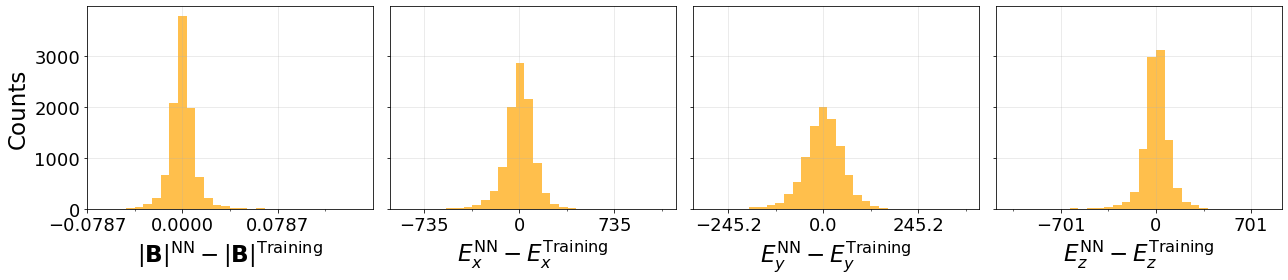

In [150]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Adjustable font sizes
scale = 1.3
label_fontsize = int(18 * scale)
tick_fontsize  = int(14 * scale)

# Errors (assumed already defined)
B3_error_train = B_true_train - B_pred_train
E1_error_train = E_true_train[:, 0] - E_pred_train[:, 0]
E2_error_train = E_true_train[:, 1] - E_pred_train[:, 1]
E3_error_train = E_true_train[:, 2] - E_pred_train[:, 2]

data_list = [
    (B3_error_train, r'$|\mathbf{B}|^{\mathrm{NN}} - |\mathbf{B}|^{\mathrm{Training}}$'),
    (E1_error_train, r'$E_x^{\mathrm{NN}} - E_x^{\mathrm{Training}}$'),
    (E2_error_train, r'$E_y^{\mathrm{NN}} - E_y^{\mathrm{Training}}$'),
    (E3_error_train, r'$E_z^{\mathrm{NN}} - E_z^{\mathrm{Training}}$')
]

fig, axs = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for i, (data, xlabel) in enumerate(data_list):
    ax = axs[i]
    ax.hist(data, bins=30, color='orange', alpha=0.7)
    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    if i == 0:
        ax.set_ylabel('Counts', fontsize=label_fontsize)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', which='both', labelsize=tick_fontsize)

    # Make x ticks denser: ~8 major ticks based on current span
    xmin, xmax = ax.get_xlim()
    step = (xmax - xmin) / 3.0 if xmax > xmin else 1.0
    ax.xaxis.set_major_locator(ticker.MultipleLocator(step))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

plt.tight_layout()
plt.savefig("/home/botingl/machine learning/Plots/GBM_Hist_training_histogram.pdf", dpi=300, facecolor='white')
plt.show()


Combine the scaled-back true and predicted values for evaluation

In [151]:
true_train_combined = np.column_stack((B_true_train, E_true_train))
pred_train_combined = np.column_stack((B_pred_train, E_pred_train))

Whole model evaluation

In [152]:
nmse_train, rmae_train, r2_whole_model_train = evaluate_whole_model(true_train_combined, pred_train_combined)
print(f"Whole Model NMSE: {nmse_train}, rMAE: {rmae_train}, R²: {r2_whole_model_train}")

Whole Model NMSE: 0.016476525327379504, rMAE: 0.06415925187157832, R²: 0.9738458116873421


Component-wise evaluation

In [153]:
mse_train_B3, mae_train_B3, r2_train_B3 = evaluate_components(B_true_train, B_pred_train)
mse_train_E1, mae_train_E1, r2_train_E1 = evaluate_components(E_true_train[:, 0], E_pred_train[:, 0])
mse_train_E2, mae_train_E2, r2_train_E2 = evaluate_components(E_true_train[:, 1], E_pred_train[:, 1])
mse_train_E3, mae_train_E3, r2_train_E3 = evaluate_components(E_true_train[:, 2], E_pred_train[:, 2])

Output the evaluation for each component

In [154]:
print(f"B3: MSE = {mse_train_B3}, MAE = {mae_train_B3}, R² = {r2_train_B3}")
print(f"E1: MSE = {mse_train_E1}, MAE = {mae_train_E1}, R² = {r2_train_E1}")
print(f"E2: MSE = {mse_train_E2}, MAE = {mae_train_E2}, R² = {r2_train_E2}")
print(f"E3: MSE = {mse_train_E3}, MAE = {mae_train_E3}, R² = {r2_train_E3}")

B3: MSE = 0.00013241122179674227, MAE = 0.007526303395133945, R² = 0.9823086027911304
E1: MSE = 15392.302423395431, MAE = 85.89849280134104, R² = 0.9540143783788191
E2: MSE = 2666.0677989784976, MAE = 38.691429575345744, R² = 0.9919490448211293
E3: MSE = 11049.248478144038, MAE = 69.7961708720911, R² = 0.9671112207582895


Save evaluation metrics to a text file

In [155]:
# metrics_train_file = os.path.join("/home/botingl/machine learning", generate_filename("evaluation_metrics_train", "txt"))
# with open(metrics_train_file, "w") as f:
#     f.write(f"Whole Model: NMSE: {nmse_train}, rMAE: {rmae_train}, R²: {r2_whole_model_train}\n")
#     f.write(f"B3: MSE = {mse_train_B3}, MAE = {mae_train_B3}, R² = {r2_train_B3}\n")
#     f.write(f"E1: MSE = {mse_train_E1}, MAE = {mae_train_E1}, R² = {r2_train_E1}\n")
#     f.write(f"E2: MSE = {mse_train_E2}, MAE = {mae_train_E2}, R² = {r2_train_E2}\n")
#     f.write(f"E3: MSE = {mse_train_E3}, MAE = {mae_train_E3}, R² = {r2_train_E3}\n")

Plot the true vs. predicted B and E values for the training set

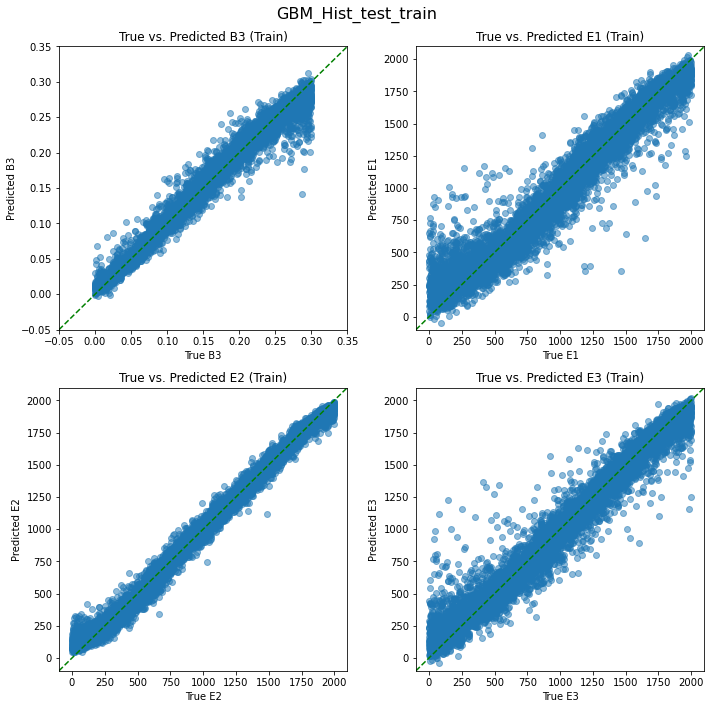

In [156]:
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.scatter(B_true_train, B_pred_train, alpha=0.5)
plt.plot([-0.05, 1.1], [-0.05, 1.1], 'g--')
plt.xlim(-0.05, 0.35)
plt.ylim(-0.05, 0.35)
plt.xlabel('True B3')
plt.ylabel('Predicted B3')
plt.title('True vs. Predicted B3 (Train)')

plt.subplot(2, 2, 2)
plt.scatter(E_true_train[:, 0], E_pred_train[:, 0], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E1')
plt.ylabel('Predicted E1')
plt.title('True vs. Predicted E1 (Train)')

plt.subplot(2, 2, 3)
plt.scatter(E_true_train[:, 1], E_pred_train[:, 1], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E2')
plt.ylabel('Predicted E2')
plt.title('True vs. Predicted E2 (Train)')

plt.subplot(2, 2, 4)
plt.scatter(E_true_train[:, 2], E_pred_train[:, 2], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E3')
plt.ylabel('Predicted E3')
plt.title('True vs. Predicted E3 (Train)')

plt.suptitle(f'{name_format}_train', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to avoid overlap with suptitle
figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_train", "png"))
# plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()

In [157]:
print("Training set evaluation done.", flush=True)

Training set evaluation done.


Evaluate the model on the testing set

In [158]:
print("Start to evaluate the testing set.", flush=True)

Start to evaluate the testing set.


In [159]:
import time

# Measure the time taken for the entire prediction process
start_time = time.time()

# Make predictions on the training data
predictions_test = model.predict(input_data_test)

# Measure the end time
end_time = time.time()

# Calculate and print the time taken
time_taken = end_time - start_time
print(f"Time taken for prediction on the entire testing set: {time_taken:.4f} seconds")

um_input = len(input_data_test)
time_each = time_taken/num_input
print(f"Time taken for prediction on each testing set: {time_each:.6f} seconds")


Time taken for prediction on the entire testing set: 0.0632 seconds
Time taken for prediction on each testing set: 0.000006 seconds


Scale back the predicted values to original range for the test data

In [160]:
B_pred_test = scaler_B3.inverse_transform(predictions_test[:, 0].reshape(-1, 1))

In [161]:
E_pred_test = np.column_stack((
    scaler_E1.inverse_transform(predictions_test[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_test[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_test[:, 3].reshape(-1, 1))
))

Scale back the true values to original range for the test data

In [162]:
B_true_test = scaler_B3.inverse_transform(target_data_test[:, 0].reshape(-1, 1))

In [163]:
E_true_test = np.column_stack((
    scaler_E1.inverse_transform(target_data_test[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(target_data_test[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(target_data_test[:, 3].reshape(-1, 1))
))

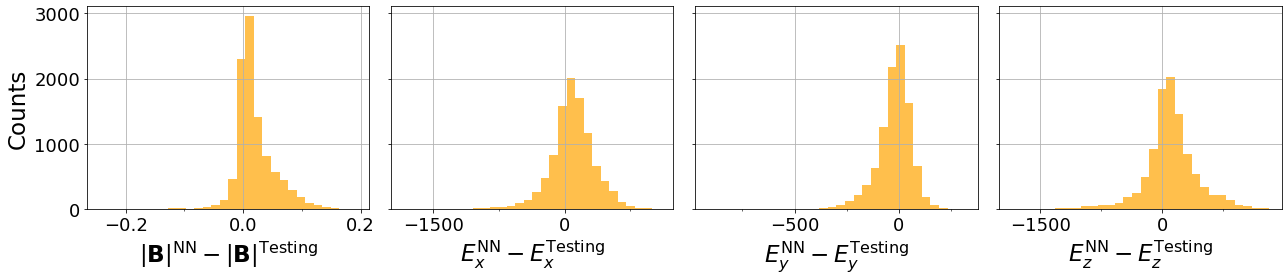

In [164]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Adjustable font sizes
scale = 1.3
label_fontsize = int(18 * scale)
tick_fontsize = int(14 * scale)

# Step 1: Calculate the errors for B3, E1, E2, E3 components
B3_error = B_true_test - B_pred_test
E1_error = E_true_test[:, 0] - E_pred_test[:, 0]
E2_error = E_true_test[:, 1] - E_pred_test[:, 1]
E3_error = E_true_test[:, 2] - E_pred_test[:, 2]

# Step 2: Create figure and subplots
fig, axs = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

# Plot histograms
axs[0].hist(B3_error, bins=30, color='orange', alpha=0.7)
axs[1].hist(E1_error, bins=30, color='orange', alpha=0.7)
axs[2].hist(E2_error, bins=30, color='orange', alpha=0.7)
axs[3].hist(E3_error, bins=30, color='orange', alpha=0.7)

# Labels
axs[0].set_xlabel(r'$|\mathbf{B}|^{\mathrm{NN}} - |\mathbf{B}|^{\mathrm{Testing}}$', fontsize=label_fontsize)
axs[0].set_ylabel('Counts', fontsize=label_fontsize)
axs[1].set_xlabel(r'$E_x^{\mathrm{NN}} - E_x^{\mathrm{Testing}}$', fontsize=label_fontsize)
axs[2].set_xlabel(r'$E_y^{\mathrm{NN}} - E_y^{\mathrm{Testing}}$', fontsize=label_fontsize)
axs[3].set_xlabel(r'$E_z^{\mathrm{NN}} - E_z^{\mathrm{Testing}}$', fontsize=label_fontsize)

# Force consistent ticks and grid
for ax in axs:
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.tick_params(axis='both', which='minor', labelsize=tick_fontsize - 2)
    ax.grid(True)

# Adjust layout
plt.tight_layout()
plt.savefig("/home/botingl/machine learning/Plots/GBM_Hist_testing_histogram.pdf", dpi=300, facecolor='white')
plt.show()



Combine the scaled-back true and predicted values for evaluation (test data)

In [165]:
true_test_combined = np.column_stack((B_true_test, E_true_test))
pred_test_combined = np.column_stack((B_pred_test, E_pred_test))

Whole model evaluation

In [166]:
nmse_test, rmae_test, r2_whole_model_test = evaluate_whole_model(true_test_combined, pred_test_combined)
print(f"Whole Model NMSE: {nmse_test}, rMAE: {rmae_test}, R²: {r2_whole_model_test}")

Whole Model NMSE: 0.1118436668712621, rMAE: 0.16674049483011608, R²: 0.8003846847157563


Component-wise evaluation

In [167]:
mse_test_B3, mae_test_B3, r2_test_B3 = evaluate_components(B_true_test, B_pred_test)
mse_test_E1, mae_test_E1, r2_test_E1 = evaluate_components(E_true_test[:, 0], E_pred_test[:, 0])
mse_test_E2, mae_test_E2, r2_test_E2 = evaluate_components(E_true_test[:, 1], E_pred_test[:, 1])
mse_test_E3, mae_test_E3, r2_test_E3 = evaluate_components(E_true_test[:, 2], E_pred_test[:, 2])

Output the evaluation for each component

In [168]:
print(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}")
print(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}")
print(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}")
print(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}")

B3: MSE = 0.0015677281080738142, MAE = 0.02649046487490175, R² = 0.7905250087054508
E1: MSE = 73366.34865168242, MAE = 202.99616668499593, R² = 0.7808161767768289
E2: MSE = 7378.506851799299, MAE = 60.640321172271506, R² = 0.9777176124641404
E3: MSE = 116821.8890089101, MAE = 241.4232206727045, R² = 0.6524799409166058


Save evaluation metrics to a text file

In [169]:
# metrics_train_file = os.path.join("/home/botingl/machine learning", generate_filename("evaluation_metrics_test", "txt"))
# with open(metrics_train_file, "w") as f:
#     f.write(f"Whole Model: NMSE: {nmse_test}, rMAE: {rmae_test}, R²: {r2_whole_model_test}\n")
#     f.write(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}\n")
#     f.write(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}\n")
#     f.write(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}\n")
#     f.write(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}\n")

Plot the true vs. predicted B and E values for the test set

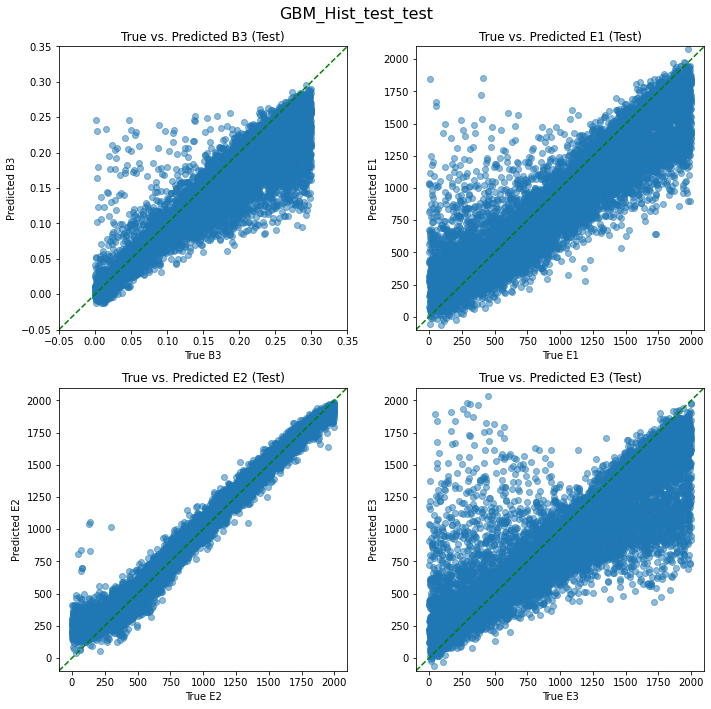

In [170]:
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.scatter(B_true_test, B_pred_test, alpha=0.5)
plt.plot([-0.05, 1.1], [-0.05, 1.1], 'g--')
plt.xlim(-0.05, 0.35)
plt.ylim(-0.05, 0.35)
plt.xlabel('True B3')
plt.ylabel('Predicted B3')
plt.title('True vs. Predicted B3 (Test)')

plt.subplot(2, 2, 2)
plt.scatter(E_true_test[:, 0], E_pred_test[:, 0], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E1')
plt.ylabel('Predicted E1')
plt.title('True vs. Predicted E1 (Test)')

plt.subplot(2, 2, 3)
plt.scatter(E_true_test[:, 1], E_pred_test[:, 1], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E2')
plt.ylabel('Predicted E2')
plt.title('True vs. Predicted E2 (Test)')

plt.subplot(2, 2, 4)
plt.scatter(E_true_test[:, 2], E_pred_test[:, 2], alpha=0.5)
plt.plot([-100, 2100], [-100, 2100], 'g--')
plt.xlim(-100, 2100)
plt.ylim(-100, 2100)
plt.xlabel('True E3')
plt.ylabel('Predicted E3')
plt.title('True vs. Predicted E3 (Test)')

plt.suptitle(f'{name_format}_test', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to avoid overlap with suptitle
figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_test", "png"))
# plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()

In [171]:
print("Testing set evaluation done.", flush=True)

Testing set evaluation done.
